In [ ]:
import pandas as pd
import numpy as np

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.decomposition import PCA

from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None

# Data Exploration

In [4]:
fp = r"C:\Users\jfurs\Desktop\Annexes OC\DS\Projet_3\fr_openfoodfacts_org_products\fr.openfoodfacts.org.products.csv"
df = pd.read_csv(fp, sep='\t', lineterminator='\n')

C:\Users\jfurs\AppData\Local\Temp\ipykernel_25688\85639532.py:2: DtypeWarning: Columns (0,19,20,24,25,26,28,35,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp, sep='\t', lineterminator='\n')


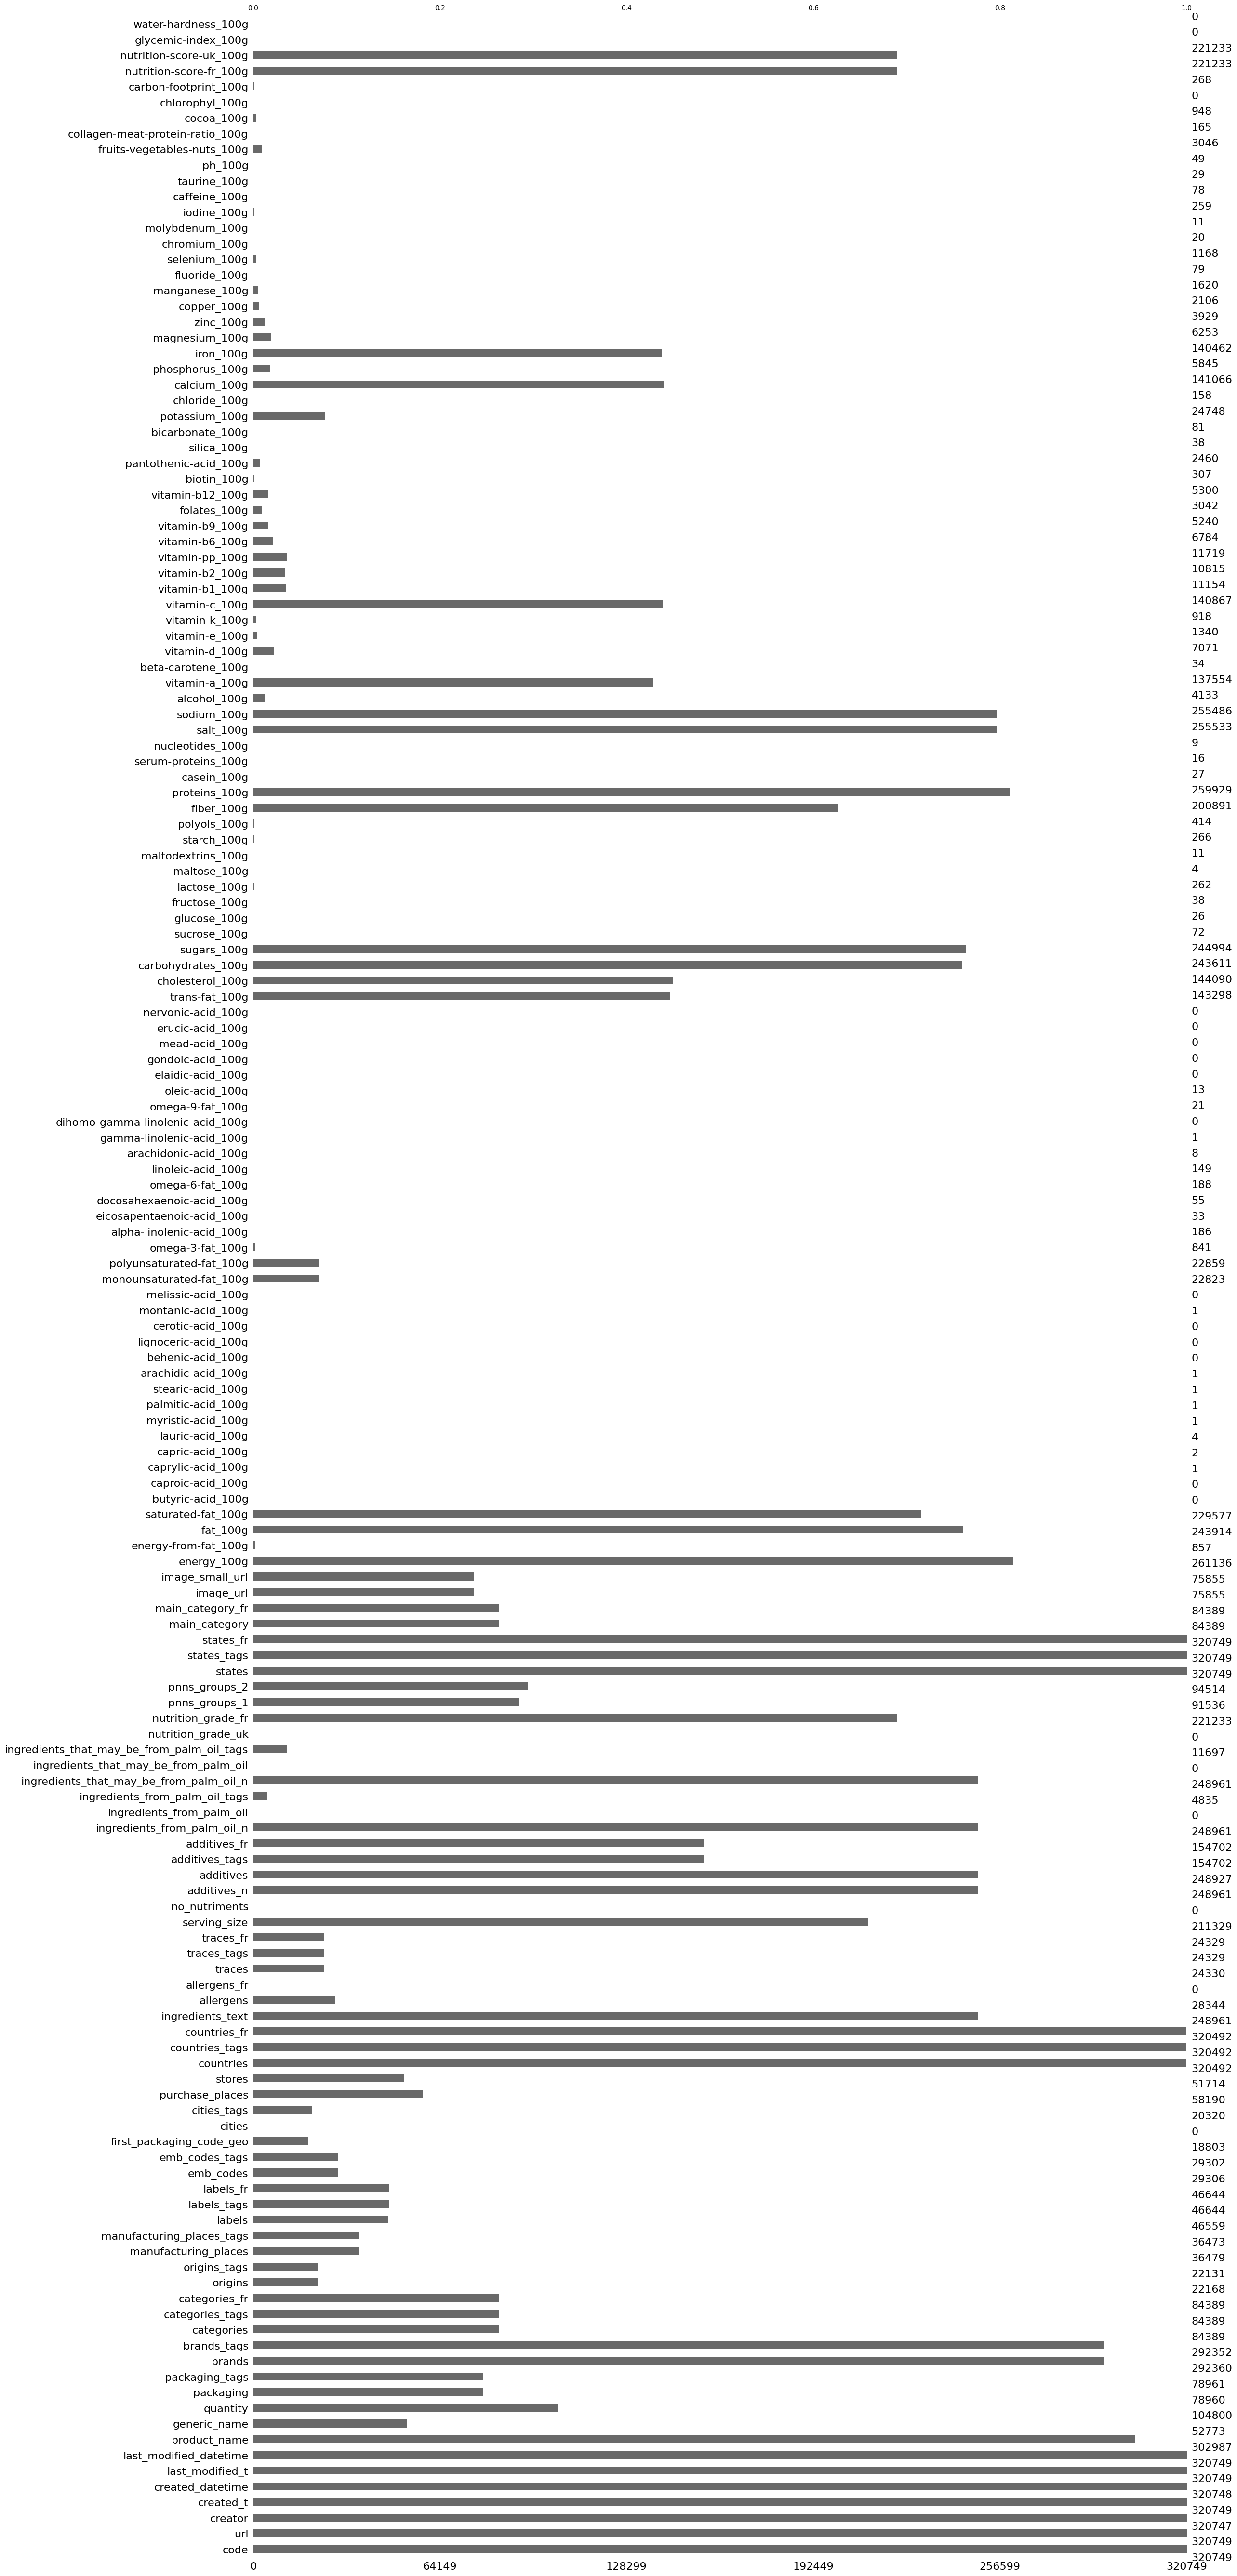

In [6]:
msno.bar(df);

In [7]:
len(df), len(df.columns)

(320749, 162)

In [8]:
# only taking Fr

df_fr = df[df['countries'].str.lower().str.contains('fr', na=False)]
df_fr

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,2.46 kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221701,2015-01-25T21:35:01Z,1489055667,2017-03-09T10:34:27Z,Lion Peanut x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN
136,39259,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221773,2015-01-25T21:36:13Z,1473538082,2016-09-10T20:08:02Z,Twix x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320738,9906410000009,http://world-fr.openfoodfacts.org/produit/9906...,agamitsudo,1373480408,2013-07-10T18:20:08Z,1451851215,2016-01-03T20:00:15Z,Roussette du Bugey (2011),Vins blanc du Bugey,750 ml,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320740,99111250,http://world-fr.openfoodfacts.org/produit/9911...,balooval,1367163039,2013-04-28T15:30:39Z,1371690556,2013-06-20T01:09:16Z,Thé vert Earl grey,thé bio équitable,50 g,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN,NaN
320741,9918,http://world-fr.openfoodfacts.org/produit/9918...,woshilapin,1430167954,2015-04-27T20:52:34Z,1430167992,2015-04-27T20:53:12Z,"Cheese cake thé vert, yuzu",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320742,9935010000003,http://world-fr.openfoodfacts.org/produit/9935...,sebleouf,1446293229,2015-10-31T12:07:09Z,1446376839,2015-11-01T11:20:39Z,Rillette d'oie,NaN,180 g,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
nan_columns = df_fr.columns[df_fr.isna().all()].tolist()
nan_columns

['cities',
 'allergens_fr',
 'no_nutriments',
 'ingredients_from_palm_oil',
 'ingredients_that_may_be_from_palm_oil',
 'nutrition_grade_uk',
 'butyric-acid_100g',
 'caproic-acid_100g',
 'caprylic-acid_100g',
 'capric-acid_100g',
 'myristic-acid_100g',
 'palmitic-acid_100g',
 'stearic-acid_100g',
 'behenic-acid_100g',
 'lignoceric-acid_100g',
 'cerotic-acid_100g',
 'melissic-acid_100g',
 'dihomo-gamma-linolenic-acid_100g',
 'elaidic-acid_100g',
 'gondoic-acid_100g',
 'mead-acid_100g',
 'erucic-acid_100g',
 'nervonic-acid_100g',
 'chlorophyl_100g',
 'glycemic-index_100g',
 'water-hardness_100g']

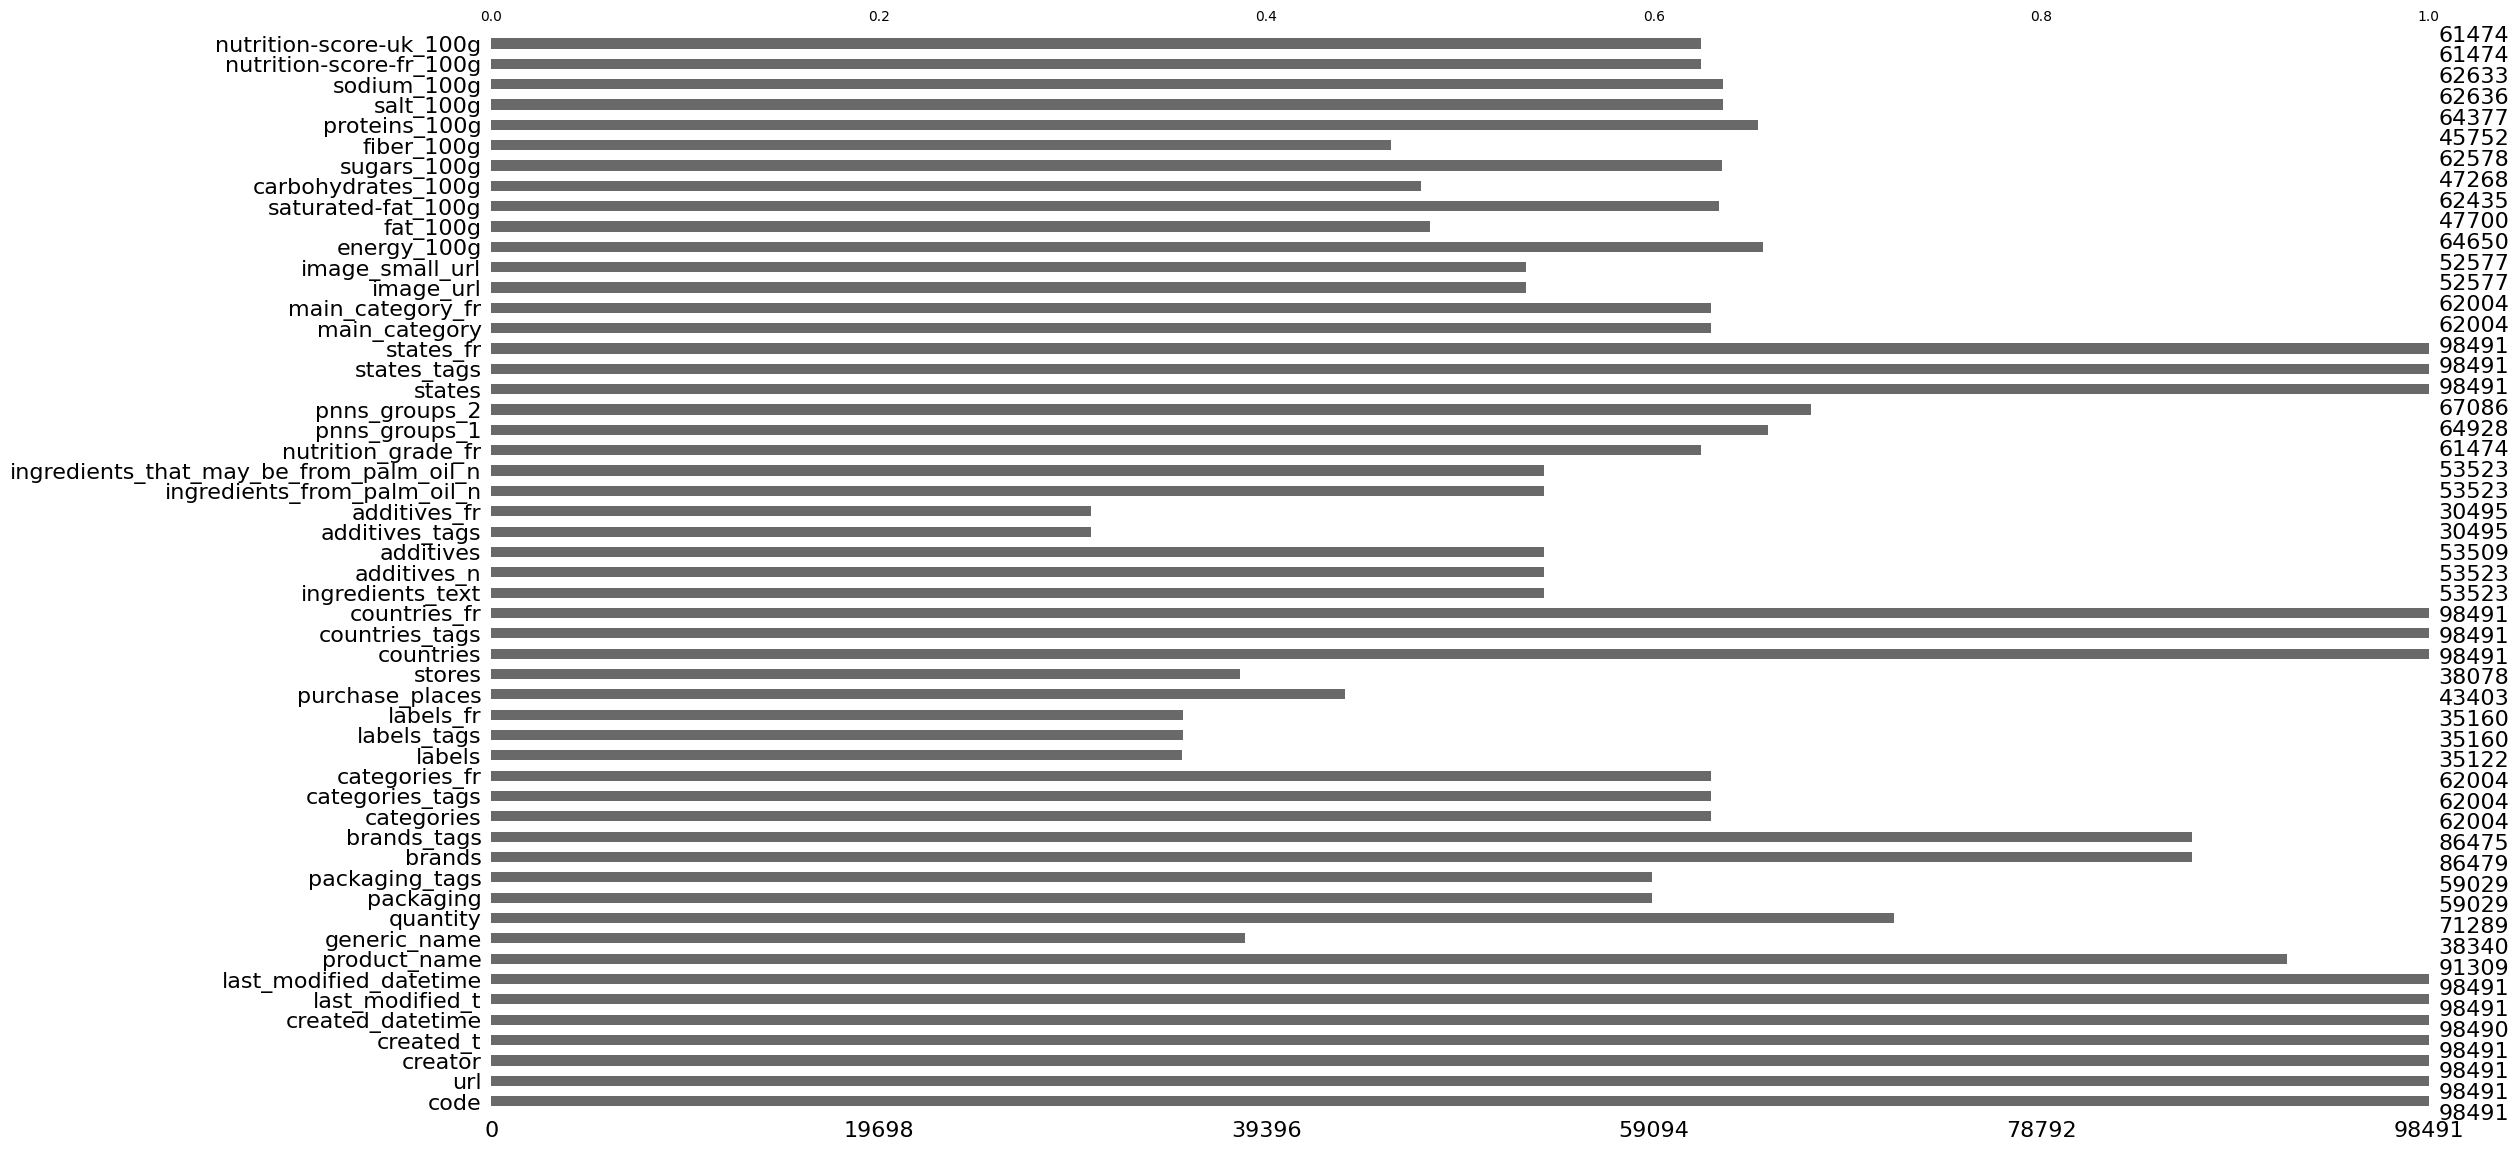

In [10]:
len_30 = int(len(df_fr) * 3/10) # decide less 30 completion = drop

cols_not_vides = []

for i in df_fr.columns:
    if df_fr[i].notna().sum() > len_30:
        cols_not_vides.append(i)

df_fr = df_fr[cols_not_vides]

msno.bar(df_fr);

In [11]:
# nettoyage valeurs dupliquées

df_fr[df_fr["code"] == 24600] # rm 519
df_fr[df_fr["code"] == 11778] # rm 9892
df_fr[df_fr["code"] == 635646] # rm 67371
df_fr[df_fr["code"] == 722810] # rm 80034

df_fr = df_fr.drop([519, 9892, 67371, 80034]).reset_index(drop=True)

In [12]:
meaningful_columns = [
    # General information
    'code', 'product_name', 'main_category_fr', 'additives_n', 

    # Nutri-Score
    'nutrition_grade_fr', 'nutrition-score-fr_100g',

    # Nutrition facts
    'energy_100g', 'fiber_100g', 'sugars_100g', 'salt_100g', 'saturated-fat_100g', 'proteins_100g', 'carbohydrates_100g'

    # others
    "additives", "additives_n", "pnns_groups_2", "pnns_groups_1", "additives_fr", "additives_tags", "main_category_fr"
    ]

In [13]:
df_fr = df_fr[['code', 'product_name', 'main_category_fr', "pnns_groups_1", "pnns_groups_2", 'nutrition_grade_fr', 'additives_n', 
               "additives_fr", 'nutrition-score-fr_100g','energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 
               "carbohydrates_100g"]]

df_fr["pnns_groups_2"] = df_fr["pnns_groups_2"].replace("unknown", np.nan)

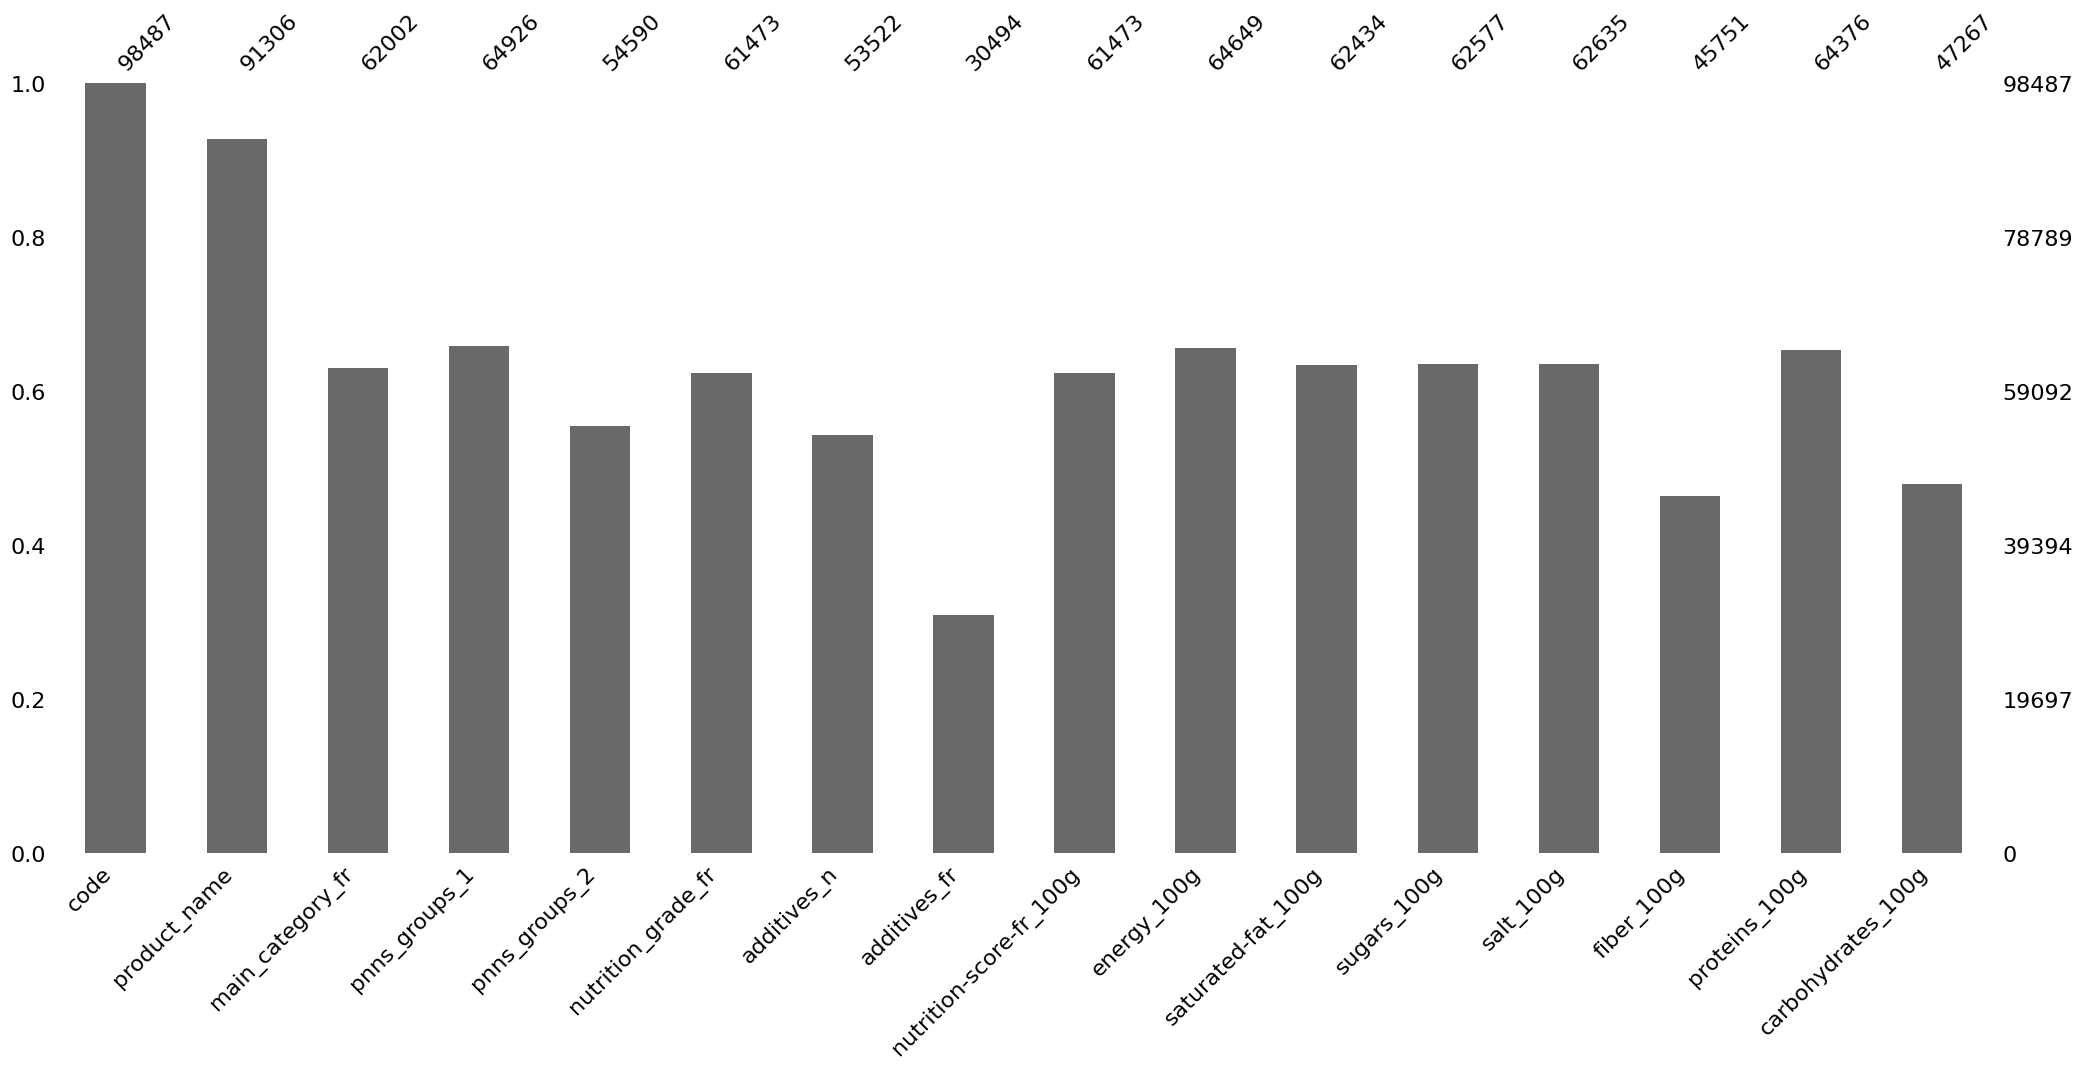

In [14]:
msno.bar(df_fr);

In [15]:
cols = ["main_category_fr", "pnns_groups_1", "pnns_groups_2"]

for i in cols:
    print(f"Column unique values for {i} : {len(df_fr[i].unique())}")

Column unique values for main_category_fr : 1613
Column unique values for pnns_groups_1 : 14
Column unique values for pnns_groups_2 : 41


# Data Imputation

In [16]:
cols_to_impute = ['additives_n', 'nutrition-score-fr_100g', 'energy_100g',
       'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g',
       'proteins_100g', "carbohydrates_100g"]

## Outliers detection

In [17]:
def count_outliers(df: pd.DataFrame, col: str):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col} : ", len(outliers)) 

for col in cols_to_impute:
    outlier_count = count_outliers(df, col)

additives_n :  9807
nutrition-score-fr_100g :  4
energy_100g :  1080
saturated-fat_100g :  17247
sugars_100g :  15308
salt_100g :  16487
fiber_100g :  14128
proteins_100g :  12592
carbohydrates_100g :  5


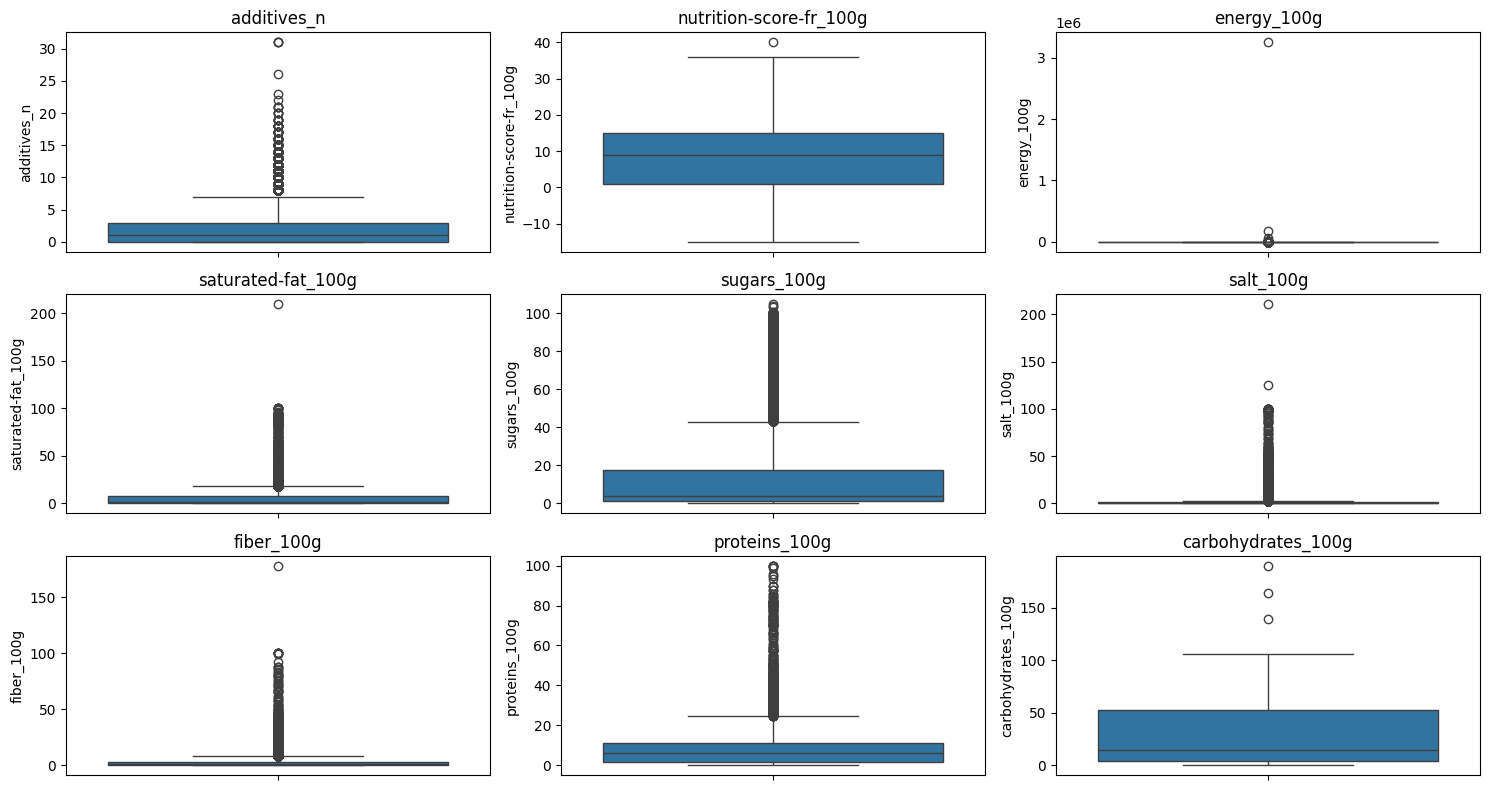

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

axes = axes.flatten()

for i, col in enumerate(df_fr[cols_to_impute]):
    sns.boxplot(data=df_fr[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.show()

## Outliers removal

In [19]:
def remove_outlier_rows(df, columns, factor=1.5):
    """
    Removes rows that are outliers in the specified numeric columns,
    but keeps rows where those columns have NaN values.

    Args:
        df (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to check for outliers.
        factor (float): The IQR multiplier for defining outlier bounds (default is 1.5).

    Returns:
        pd.DataFrame: A DataFrame with outliers removed, but NaNs preserved.
    """
    mask = pd.Series(True, index=df.index)

    for col in columns:
        if col not in df.columns:
            continue  # Skip missing columns safely

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Keep rows that are within bounds OR NaN
        mask &= df[col].between(lower_bound, upper_bound) | df[col].isna()

    return df[mask]


In [20]:
df_cleaned = remove_outlier_rows(df_fr, cols_to_impute)
df_cleaned.isna().sum()

code                           0
product_name                7089
main_category_fr           31044
pnns_groups_1              28946
pnns_groups_2              36838
nutrition_grade_fr         36024
additives_n                38820
additives_fr               57744
nutrition-score-fr_100g    36024
energy_100g                33518
saturated-fat_100g         35456
sugars_100g                35376
salt_100g                  35254
fiber_100g                 46796
proteins_100g              33731
carbohydrates_100g         45380
dtype: int64

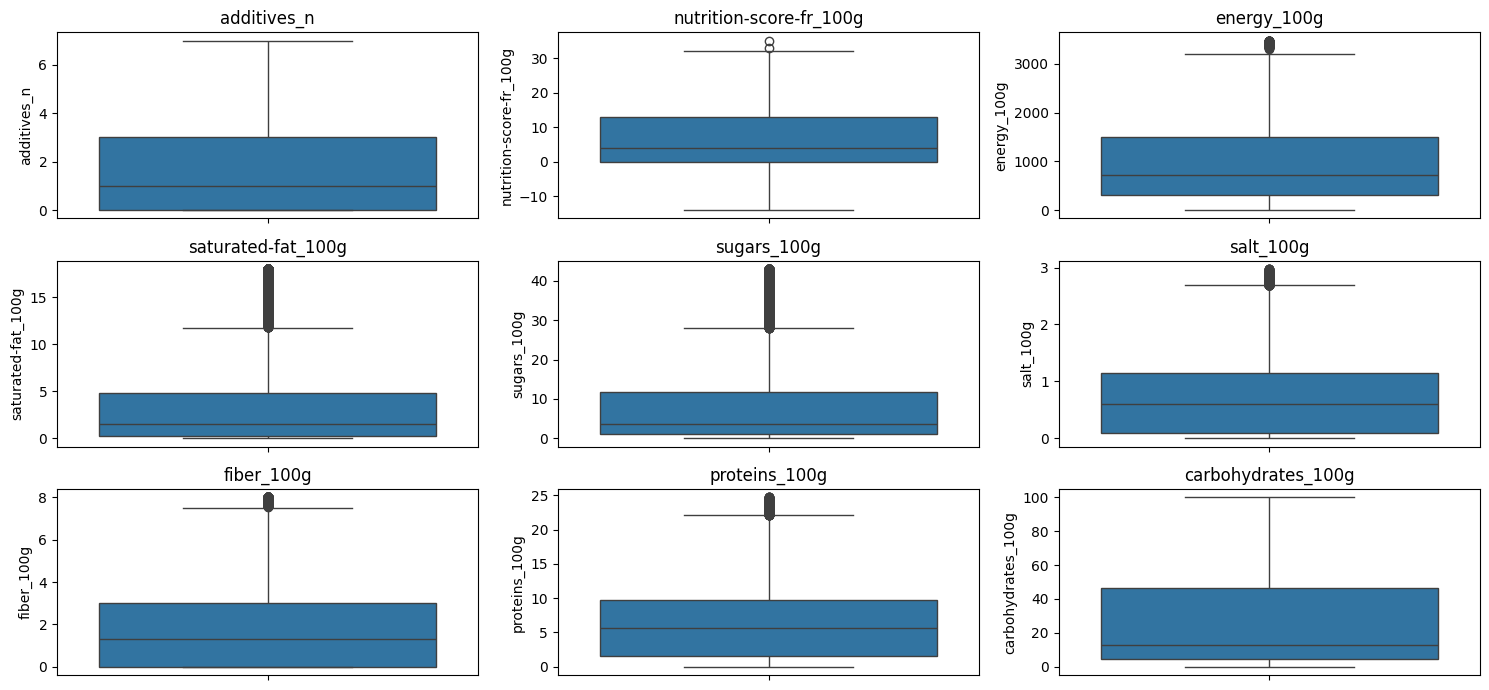

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 7))

axes = axes.flatten()

for i, col in enumerate(df_cleaned[cols_to_impute]):
    sns.boxplot(data=df_cleaned[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.show()

## Imputation

### Utils

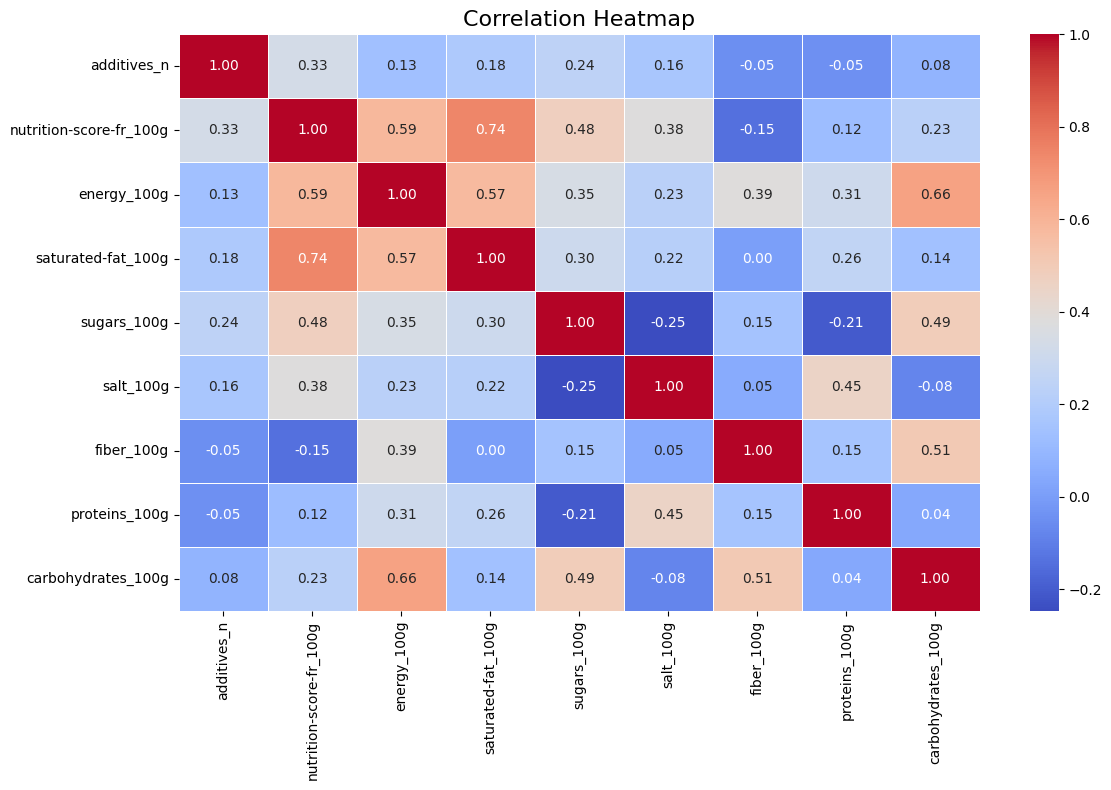

In [22]:
# find possible correclations for linear regression imputation

corr_matrix = df_cleaned[cols_to_impute].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)

plt.tight_layout()
plt.show()

In [23]:
def plot_histogram(df: pd.DataFrame, col1: str, col2: str): 
    # Sturges' method
    bins_col1 = int(np.ceil(np.log2(len(df[col1])) + 1))
    bins_col2 = int(np.ceil(np.log2(len(df[col2])) + 1))
    
    plt.figure(figsize=(9, 4))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col1], bins=bins_col1, kde=True, color='blue')
    plt.title(f'Distribution of {col1}')
    plt.ylabel('')  
    
    plt.subplot(1, 2, 2)
    sns.histplot(df[col2], bins=bins_col2, kde=True, color='green')
    plt.title(f'Distribution of {col2}')
    plt.ylabel('')
    
    plt.show()

In [24]:
df_cleaned = df_cleaned.reset_index(drop=True)
df = df_cleaned.copy()

In [25]:
def standardize_data(X):
    scaler = StandardScaler()
    scaler.fit(X)
    X_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
    return X_scaled

In [26]:
def evaluate_knn_rmse(X, y, max_k=30):
    combined = pd.concat([X, y], axis=1).dropna()
    X_clean = combined.drop(columns=y.name)
    y_clean = combined[y.name]

    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
    scores = []

    for k in range(1, max_k):
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        scores.append(rmse)

    return scores

In [27]:
def knn_impute(df_numeric, n_neighbors):
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_array = imputer.fit_transform(df_numeric)
    return pd.DataFrame(imputed_array, columns=df_numeric.columns, index=df_numeric.index)

In [28]:
def find_best_neighbors(df, col_to_impute):
    df_numeric = df.select_dtypes(include=[np.number])
    if col_to_impute not in df_numeric.columns:
        raise ValueError(f"Column '{col_to_impute}' must be numeric to evaluate KNN RMSE.")

    y = df_numeric[col_to_impute]
    X = df_numeric.drop(columns=[col_to_impute])
    X_scaled = standardize_data(X)

    rmse_scores = evaluate_knn_rmse(X_scaled, y)
    return rmse_scores.index(min(rmse_scores)) + 1

In [29]:
def impute_knn_column(df, col_to_impute):
    """"""
    df_numeric = df.select_dtypes(include=[np.number])
    if col_to_impute not in df_numeric.columns:
        raise ValueError(f"Column '{col_to_impute}' must be numeric.")

    optimal_k = find_best_neighbors(df, col_to_impute)

    features = df_numeric.drop(columns=[col_to_impute])
    target = df_numeric[[col_to_impute]]

    features_imputed = knn_impute(features, optimal_k)

    df_combined = features_imputed.copy()
    df_combined[col_to_impute] = target

    df_imputed = knn_impute(df_combined, optimal_k)

    return df_imputed[col_to_impute].tolist()

In [30]:
# MF imputer
imputer_med = SimpleImputer(missing_values=np.nan, strategy='median')

def get_filled_values(df, group_col, value_col):
    """
    Fills missing values in `value_col` using the mean of its group based on `group_col`.
    
    If group is missing or group has no mean, the value remains NaN.
    
    Args:
        df (pd.DataFrame): Input DataFrame (can include non-numeric columns).
        group_col (str): Name of the column to group by (e.g., 'pnns_groups_2').
        value_col (str): Name of the numeric column to fill (e.g., 'proteins_100g').

    Returns:
        list: A list of values with NaNs filled where group means are available.
    """
    if value_col not in df.select_dtypes(include=[np.number]).columns:
        raise ValueError(f"'{value_col}' must be a numeric column.")

    # Compute group means (ignoring NaNs)
    mean_dict = df.groupby(group_col, dropna=True)[value_col].mean().to_dict()

    def fill(row):
        val = row[value_col]
        group = row[group_col]

        if pd.notna(val):
            return val
        if pd.isna(group):
            return np.nan
        return mean_dict.get(group, np.nan)

    return df.apply(fill, axis=1).tolist()


### Actions

#### Fiber100g

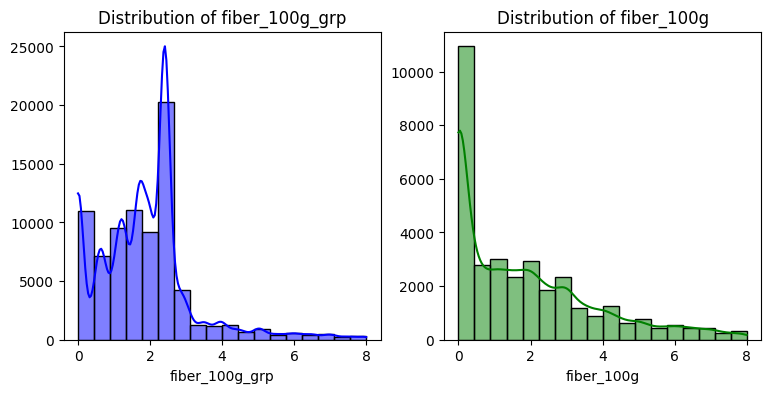

In [31]:
# knn
# imputed_values = impute_knn_column(df, 'fiber_100g')
# df["fiber_100g_knn"] = imputed_values

# imputing grp
df['fiber_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "fiber_100g")
df['fiber_100g_grp'] = get_filled_values(df, "pnns_groups_2", "fiber_100g_grp")
df['fiber_100g_grp'] = get_filled_values(df, "pnns_groups_1", "fiber_100g_grp")

imputed_values = impute_knn_column(df, 'fiber_100g_grp')
df["fiber_100g_grp"] = imputed_values

# df['fiber_100g_grp'] = imputer_med.fit_transform(df[['fiber_100g_grp']])

# plot_histogram(df, "fiber_100g_knn", 'fiber_100g')
plot_histogram(df, "fiber_100g_grp", 'fiber_100g')

df["fiber_100g"] = df["fiber_100g_grp"]

df.drop(columns=["fiber_100g_grp"], inplace=True)
# df.drop(columns=["fiber_100g_knn", "fiber_100g_grp"], inplace=True)

#### Salt_100g

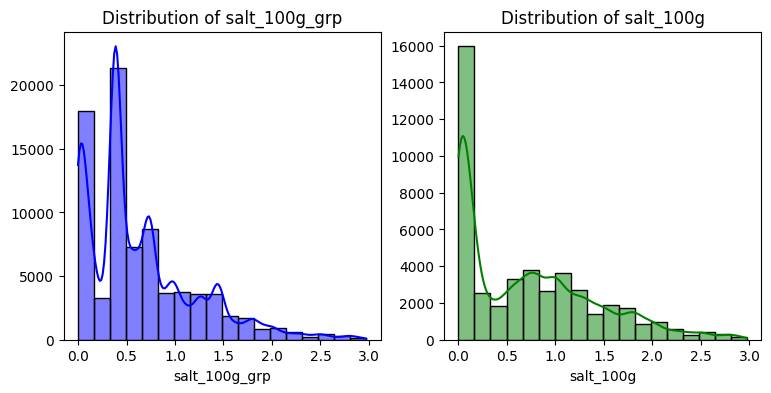

In [32]:
# knn
# imputed_values = impute_knn_column(df, 'salt_100g')
# df["salt_100g_knn"] = imputed_values

# imputing grp
df['salt_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "salt_100g")
df['salt_100g_grp'] = get_filled_values(df, "pnns_groups_2", "salt_100g")
df['salt_100g_grp'] = get_filled_values(df, "pnns_groups_1", "salt_100g")

imputed_values = impute_knn_column(df, 'salt_100g_grp')
df["salt_100g_grp"] = imputed_values

# df['salt_100g_grp'] = imputer_med.fit_transform(df[['salt_100g_grp']])

imputed_values = impute_knn_column(df, 'salt_100g_grp')
df["salt_100g_grp"] = imputed_values

# plot_histogram(df, "salt_100g_knn", 'salt_100g')
plot_histogram(df, "salt_100g_grp", 'salt_100g')

df["salt_100g"] = df["salt_100g_grp"]

df.drop(columns=["salt_100g_grp"], inplace=True)
# df.drop(columns=["salt_100g_knn", "salt_100g_grp"], inplace=True)

#### Proteins_100g

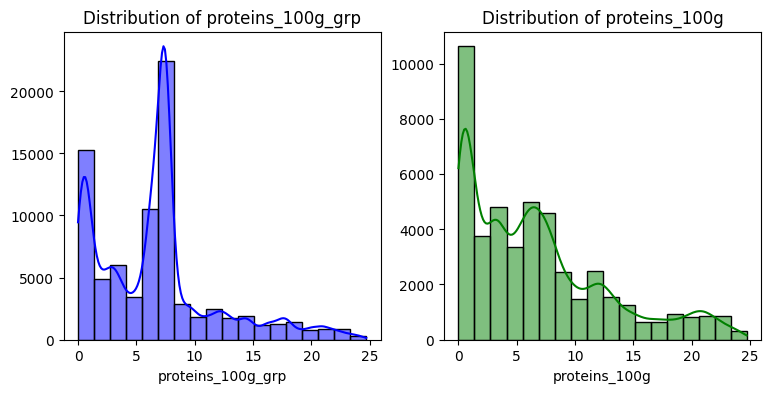

In [33]:
# knn
# imputed_values = impute_knn_column(df, 'proteins_100g')
# df["proteins_100g_knn"] = imputed_values

# imputing grp
df['proteins_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "proteins_100g")
df['proteins_100g_grp'] = get_filled_values(df, "pnns_groups_2", "proteins_100g_grp")
df['proteins_100g_grp'] = get_filled_values(df, "pnns_groups_1", "proteins_100g_grp")

imputed_values = impute_knn_column(df, 'proteins_100g_grp')
df["proteins_100g_grp"] = imputed_values

# df['proteins_100g_grp'] = imputer_med.fit_transform(df[['proteins_100g_grp']])

# plot_histogram(df, "proteins_100g_knn", 'proteins_100g')
plot_histogram(df, "proteins_100g_grp", 'proteins_100g')

df["proteins_100g"] = df["proteins_100g_grp"]

df.drop(columns=["proteins_100g_grp"], inplace=True)
# df.drop(columns=["proteins_100g_knn", "proteins_100g_grp"], inplace=True)

#### Carbohydrates_100g

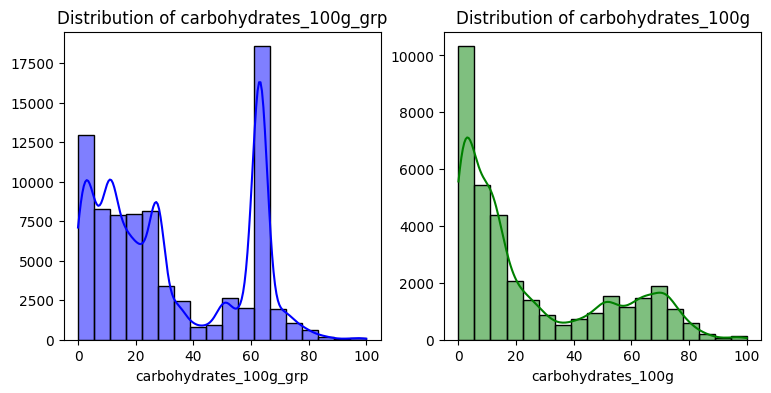

In [34]:
# knn
# imputed_values = impute_knn_column(df, 'carbohydrates_100g')
# df["carbohydrates_100g_knn"] = imputed_values

# imputing grp
df['carbohydrates_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "carbohydrates_100g")
df['carbohydrates_100g_grp'] = get_filled_values(df, "pnns_groups_2", "carbohydrates_100g_grp")
df['carbohydrates_100g_grp'] = get_filled_values(df, "pnns_groups_1", "carbohydrates_100g_grp")

imputed_values = impute_knn_column(df, 'carbohydrates_100g_grp')
df["carbohydrates_100g_grp"] = imputed_values

# df['carbohydrates_100g_grp'] = imputer_med.fit_transform(df[['carbohydrates_100g_grp']])

# plot_histogram(df, "carbohydrates_100g_knn", 'carbohydrates_100g')
plot_histogram(df, "carbohydrates_100g_grp", 'carbohydrates_100g')

df["carbohydrates_100g"] = df["carbohydrates_100g_grp"]

df.drop(columns=["carbohydrates_100g_grp"], inplace=True)
# df.drop(columns=["carbohydrates_100g_knn", "carbohydrates_100g_grp"], inplace=True)

#### Sugars_100g

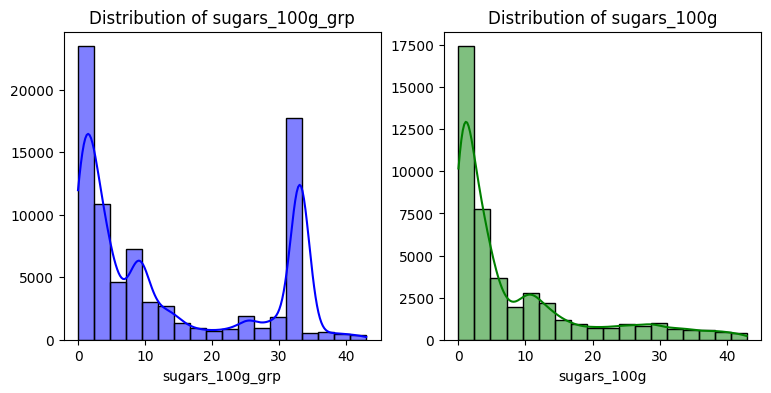

In [35]:
# knn
# imputed_values = impute_knn_column(df, 'sugars_100g')
# df["sugars_100g_knn"] = imputed_values

# imputing grp
df['sugars_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "sugars_100g")
df['sugars_100g_grp'] = get_filled_values(df, "pnns_groups_2", "sugars_100g_grp")
df['sugars_100g_grp'] = get_filled_values(df, "pnns_groups_1", "sugars_100g_grp")

imputed_values = impute_knn_column(df, 'sugars_100g_grp')
df["sugars_100g_grp"] = imputed_values

# df['sugars_100g_grp'] = imputer_med.fit_transform(df[['sugars_100g_grp']])

# plot_histogram(df, "sugars_100g_knn", 'sugars_100g')
plot_histogram(df, "sugars_100g_grp", 'sugars_100g')

df["sugars_100g"] = df["sugars_100g_grp"]

df.drop(columns=["sugars_100g_grp"], inplace=True)
# df.drop(columns=["sugars_100g_knn", "sugars_100g_grp"], inplace=True)

#### Saturated-fat_100g

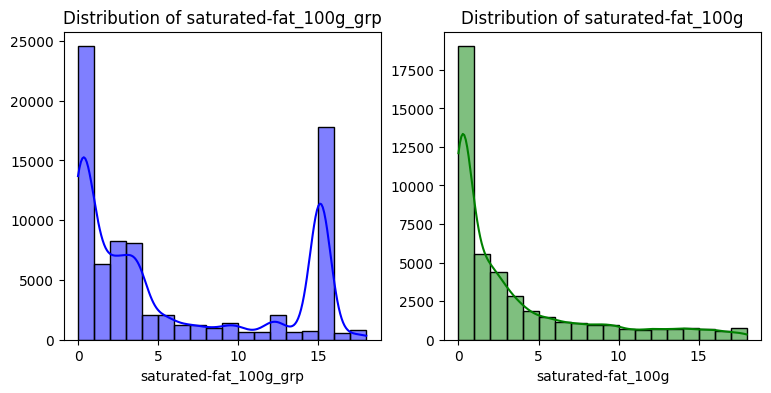

In [36]:
# knn
# imputed_values = impute_knn_column(df, 'saturated-fat_100g')
# df["saturated-fat_100g_knn"] = imputed_values

# imputing grp
df['saturated-fat_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "saturated-fat_100g")
df['saturated-fat_100g_grp'] = get_filled_values(df, "pnns_groups_2", "saturated-fat_100g_grp")
df['saturated-fat_100g_grp'] = get_filled_values(df, "pnns_groups_1", "saturated-fat_100g_grp")

imputed_values = impute_knn_column(df, 'saturated-fat_100g_grp')
df["saturated-fat_100g_grp"] = imputed_values

# df['saturated-fat_100g_grp'] = imputer_med.fit_transform(df[['saturated-fat_100g_grp']])

# plot_histogram(df, "saturated-fat_100g_knn", 'saturated-fat_100g')
plot_histogram(df, "saturated-fat_100g_grp", 'saturated-fat_100g')

df["saturated-fat_100g"] = df["saturated-fat_100g_grp"]

df.drop(columns=["saturated-fat_100g_grp"], inplace=True)
# df.drop(columns=["saturated-fat_100g_knn", "saturated-fat_100g_grp"], inplace=True)

#### Nutrition-score-fr_100g

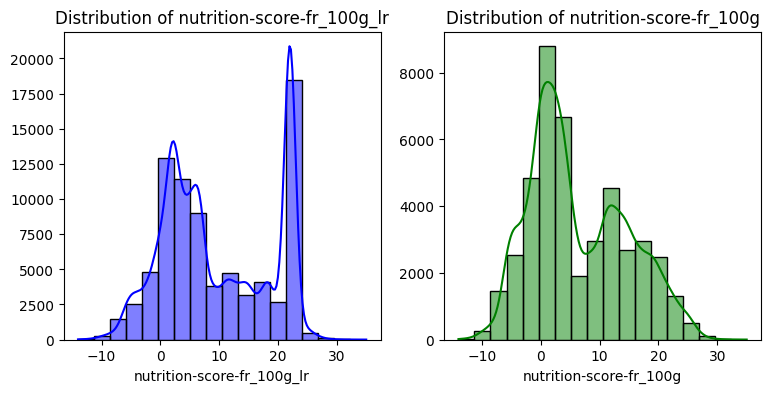

In [37]:
train_data = df[['saturated-fat_100g', 'nutrition-score-fr_100g']].dropna()

X_train = train_data[['saturated-fat_100g']]
y_train = train_data['nutrition-score-fr_100g']

predict_data = df[df['nutrition-score-fr_100g'].isna()]
predict_data = predict_data[predict_data['saturated-fat_100g'].notna()]
X_predict = predict_data[['saturated-fat_100g']]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_predict)

df['nutrition-score-fr_100g_lr'] = df['nutrition-score-fr_100g'].copy()
df.loc[X_predict.index, 'nutrition-score-fr_100g_lr'] = y_pred

plot_histogram(df, "nutrition-score-fr_100g_lr", 'nutrition-score-fr_100g')

# knn
# imputed_values = impute_knn_column(df, 'nutrition-score-fr_100g')
# df["nutrition-score-fr_100g_knn"] = imputed_values

# plot_histogram(df, "nutrition-score-fr_100g_knn", 'nutrition-score-fr_100g')

df["nutrition-score-fr_100g"] = df["nutrition-score-fr_100g_lr"]

df.drop(columns=["nutrition-score-fr_100g_lr"], inplace=True)
# df.drop(columns=["nutrition-score-fr_100g_knn", "nutrition-score-fr_100g_lr"], inplace=True)

#### Energy_100g

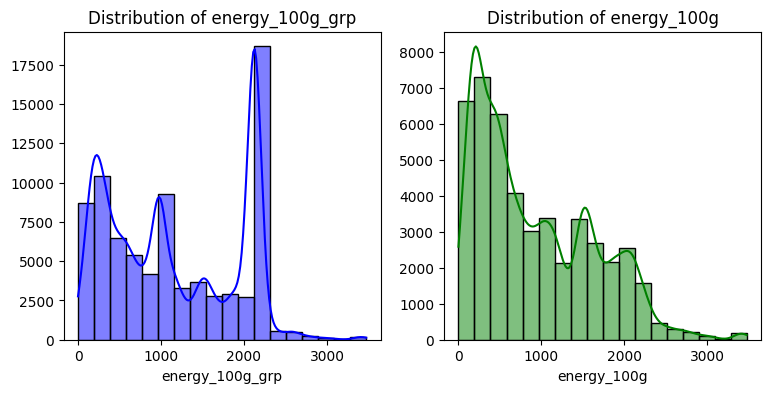

In [38]:
# KNN

# knn
# imputed_values = impute_knn_column(df, 'energy_100g')
# df["energy_100g_knn"] = imputed_values

# imputing grp
df['energy_100g_grp'] = get_filled_values(df, "nutrition_grade_fr", "energy_100g")
df['energy_100g_grp'] = get_filled_values(df, "pnns_groups_2", "energy_100g_grp")
df['energy_100g_grp'] = get_filled_values(df, "pnns_groups_1", "energy_100g_grp")

imputed_values = impute_knn_column(df, 'energy_100g_grp')
df["energy_100g_grp"] = imputed_values

# df['energy_100g_grp'] = imputer_med.fit_transform(df[['energy_100g_grp']])

# plot_histogram(df, "energy_100g_knn", 'energy_100g')
plot_histogram(df, "energy_100g_grp", 'energy_100g')

df["energy_100g"] = df["energy_100g_grp"]

df.drop(columns=["energy_100g_grp"], inplace=True)
# df.drop(columns=["energy_100g_knn", "energy_100g_grp"], inplace=True)

#### Additives_n

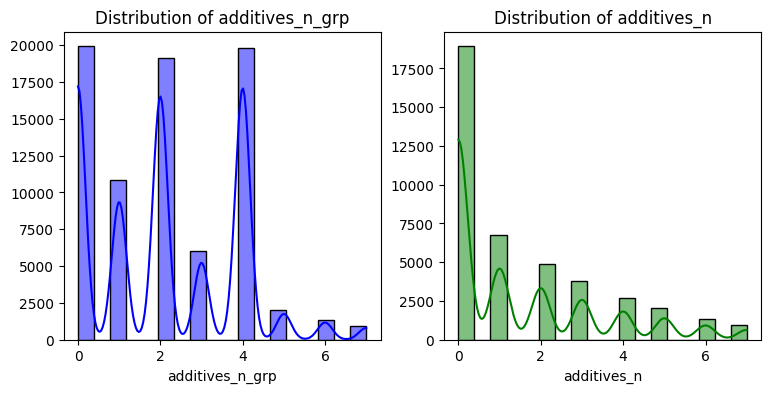

In [39]:
# knn
# imputed_values = impute_knn_column(df, 'additives_n')
# df["additives_n_knn"] = imputed_values

# imputing grp
df['additives_n_grp'] = get_filled_values(df, "nutrition_grade_fr", "additives_n")
df['additives_n_grp'] = get_filled_values(df, "pnns_groups_2", "additives_n_grp")
df['additives_n_grp'] = get_filled_values(df, "pnns_groups_1", "additives_n_grp")

imputed_values = impute_knn_column(df, 'additives_n_grp')
df["additives_n_grp"] = imputed_values

# df['additives_n_grp'] = imputer_med.fit_transform(df[['additives_n_grp']])

# df["additives_n_knn"] = df["additives_n_knn"].round(0)
df["additives_n_grp"] = df["additives_n_grp"].round(0)

# plot_histogram(df, "additives_n_knn", 'additives_n')
plot_histogram(df, "additives_n_grp", 'additives_n')

df["additives_n"] = df["additives_n_grp"]

df.drop(columns=["additives_n_grp"], inplace=True)
# df.drop(columns=["additives_n_knn", "additives_n_grp"], inplace=True)

# END

In [40]:
df.to_csv(r"C:\Users\jfurs\Desktop\Annexes OC\DS\Projet_3\fr_openfoodfacts_org_products\output.csv", index=False)